In [136]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [137]:
import os
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)

def save_figure(filename):
    plt.tight_layout()
    plt.savefig(
        f"../figures/{filename}",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

In [138]:
student_info = pd.read_csv("../data/raw/studentInfo.csv")
student_assessment = pd.read_csv("../data/raw/studentAssessment.csv")
student_registration = pd.read_csv("../data/raw/studentRegistration.csv")
student_vle = pd.read_csv("../data/raw/studentVle.csv")
vle = pd.read_csv("../data/raw/vle.csv")
assessments = pd.read_csv("../data/raw/assessments.csv")
courses = pd.read_csv("../data/raw/courses.csv")

In [139]:
tables = {
    "student_info": student_info,
    "student_assessment": student_assessment,
    "student_registration": student_registration,
    "student_vle": student_vle,
    "vle": vle,
    "assessments": assessments,
    "courses": courses
}

for name, df in tables.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")

student_info: 32593 rows, 12 columns
student_assessment: 173912 rows, 5 columns
student_registration: 32593 rows, 5 columns
student_vle: 10655280 rows, 6 columns
vle: 6364 rows, 6 columns
assessments: 206 rows, 6 columns
courses: 22 rows, 3 columns


In [140]:
student_info.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass


In [141]:
student_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   code_module           32593 non-null  str  
 1   code_presentation     32593 non-null  str  
 2   id_student            32593 non-null  int64
 3   gender                32593 non-null  str  
 4   region                32593 non-null  str  
 5   highest_education     32593 non-null  str  
 6   imd_band              31482 non-null  str  
 7   age_band              32593 non-null  str  
 8   num_of_prev_attempts  32593 non-null  int64
 9   studied_credits       32593 non-null  int64
 10  disability            32593 non-null  str  
 11  final_result          32593 non-null  str  
dtypes: int64(3), str(9)
memory usage: 3.0 MB


In [142]:
student_info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

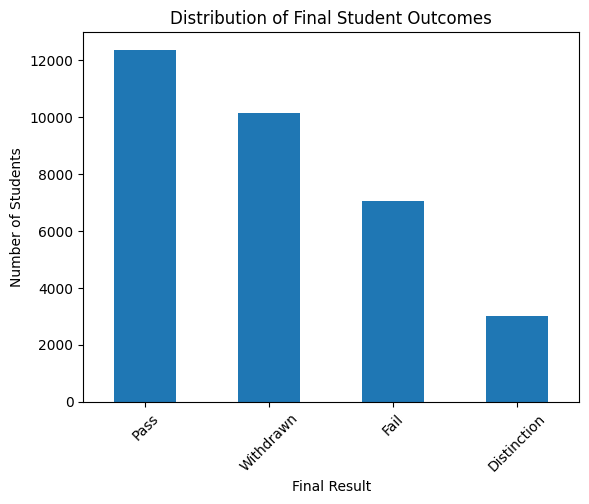

In [143]:
student_info["final_result"].value_counts().plot(kind="bar")
plt.title("Distribution of Final Student Outcomes")
plt.xlabel("Final Result")
plt.ylabel("Number of Students")
plt.xticks(rotation=45)
plt.show()

In [144]:
plt.figure(figsize=(10,6))

# plotting code

plt.tight_layout()
plt.savefig(
    "../figures/final_result.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<Figure size 1000x600 with 0 Axes>

In [145]:
student_info["final_result"].value_counts()

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64

In [146]:
student_info.isnull().sum()

code_module                0
code_presentation          0
id_student                 0
gender                     0
region                     0
highest_education          0
imd_band                1111
age_band                   0
num_of_prev_attempts       0
studied_credits            0
disability                 0
final_result               0
dtype: int64

#The dataset contains minimal missing data. Only the imd_band variable contains missing values (3.4% of records), while all other demographic and outcome variables are complete. This reduces preprocessing complexity and allows focus on feature engineering and predictive modeling.

In [147]:
# Create Analysis Dataset

engagement = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

analysis_df = student_info.merge(
    engagement,
    on="id_student",
    how="left"
)

In [148]:
(
    student_info.isnull().sum()
    / len(student_info)
    * 100
).sort_values(ascending=False)

imd_band                3.408707
code_module             0.000000
id_student              0.000000
code_presentation       0.000000
gender                  0.000000
region                  0.000000
highest_education       0.000000
age_band                0.000000
num_of_prev_attempts    0.000000
studied_credits         0.000000
disability              0.000000
final_result            0.000000
dtype: float64

In [149]:
student_info.columns

Index(['code_module', 'code_presentation', 'id_student', 'gender', 'region',
       'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts',
       'studied_credits', 'disability', 'final_result'],
      dtype='str')

In [150]:
student_info["gender"].value_counts()

gender
M    17875
F    14718
Name: count, dtype: int64

In [151]:
student_info["highest_education"].value_counts()

highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64

In [152]:
student_info["age_band"].value_counts()

age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

In [153]:
student_info["disability"].value_counts()

disability
N    29429
Y     3164
Name: count, dtype: int64

In [154]:
pd.crosstab(
    student_info["highest_education"],
    student_info["final_result"]
)

final_result,Distinction,Fail,Pass,Withdrawn
highest_education,,,,
A Level or Equivalent,1496,2707,5812,4030
HE Qualification,697,790,1960,1283
Lower Than A Level,727,3426,4385,4620
No Formal quals,16,95,87,149
Post Graduate Qualification,88,34,117,74


In [155]:
engagement = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

engagement.head()

,id_student,sum_click
0,6516,2791
1,8462,656
2,11391,934
3,23629,161
4,23698,910


In [156]:
analysis_df = student_info.merge(
    engagement,
    on="id_student",
    how="left"
)

In [157]:
analysis_df.groupby(
    "final_result"
)["sum_click"].mean()

final_result
Distinction    3106.433201
Fail            833.788213
Pass           2171.110374
Withdrawn       835.010079
Name: sum_click, dtype: float64

#Students who engage heavily with course materials tend to earn higher grades, while students with low engagement are much more likely to fail or withdraw#


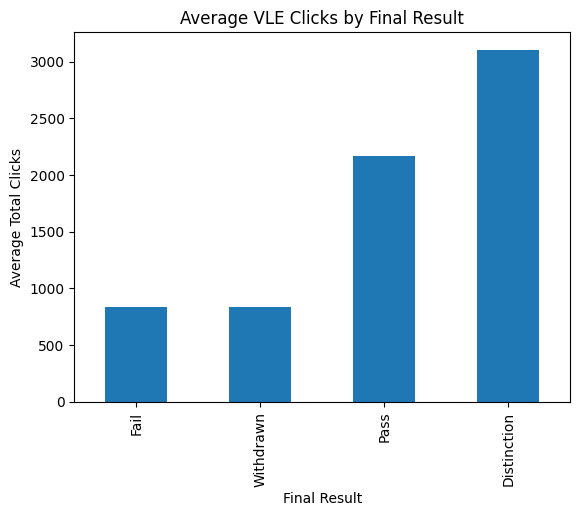

In [158]:
import matplotlib.pyplot as plt

analysis_df.groupby("final_result")["sum_click"].mean().sort_values().plot(
    kind="bar"
)

plt.title("Average VLE Clicks by Final Result")
plt.ylabel("Average Total Clicks")
plt.xlabel("Final Result")
plt.show()

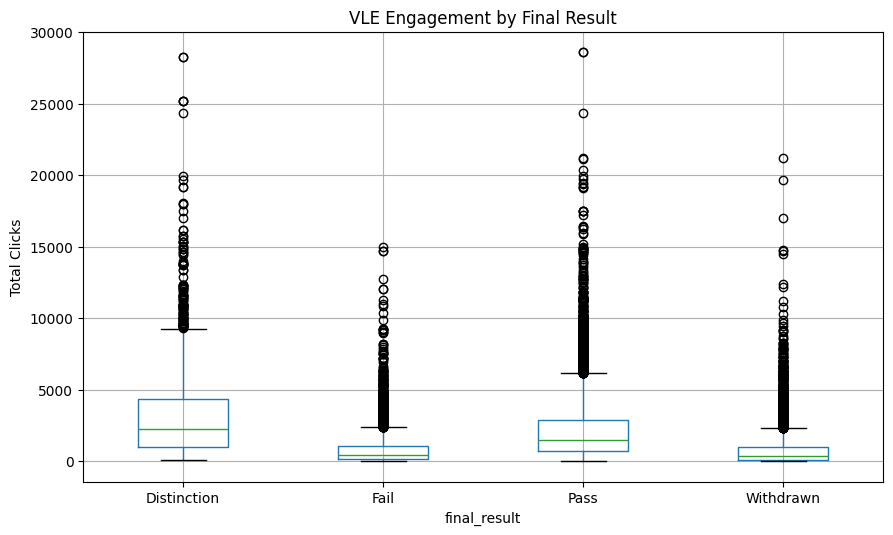

In [159]:
analysis_df.boxplot(
    column="sum_click",
    by="final_result",
    figsize=(10,6)
)

plt.title("VLE Engagement by Final Result")
plt.suptitle("")
plt.ylabel("Total Clicks")
plt.show()

### Initial Finding: Student Engagement

Student engagement, measured through total VLE clicks, appears strongly associated with academic outcomes.

Average total clicks by outcome:

- Distinction: 3,106
- Pass: 2,171
- Fail: 834
- Withdrawn: 835

Students who achieved distinctions interacted with the learning platform nearly four times more than students who failed or withdrew. This suggests that engagement metrics may serve as valuable predictors in machine learning models designed to identify at-risk students.

In [160]:
analysis_df.groupby("final_result")["studied_credits"].mean()

final_result
Distinction    71.759259
Fail           76.086926
Pass           74.220937
Withdrawn      91.430189
Name: studied_credits, dtype: float64

In [161]:
pd.crosstab(
    student_info["highest_education"],
    student_info["final_result"],
    normalize="index"
) * 100

final_result,Distinction,Fail,Pass,Withdrawn
highest_education,,,,
A Level or Equivalent,10.651477,19.273763,41.381274,28.693485
HE Qualification,14.735729,16.701903,41.437632,27.124736
Lower Than A Level,5.525156,26.037392,33.325733,35.111719
No Formal quals,4.610951,27.377522,25.072046,42.939481
Post Graduate Qualification,28.115016,10.862620,37.380192,23.642173


What this tells us

There is a very strong educational attainment gradient:

Students with postgraduate qualifications are over 6 times more likely to earn a distinction than students with no formal qualifications.
Students with no formal qualifications are almost twice as likely to withdraw as students with postgraduate qualifications.
As prior education decreases, failure and withdrawal rates consistently increase.

From a sociology perspective, this is exactly the kind of pattern that supports theories about educational capital and unequal access to academic success.

Two powerful predictors:  engagement (sum_click), and educational background (highest_education)

Students with higher levels of prior education achieved substantially better outcomes. Students holding postgraduate qualifications earned distinctions at a rate of 28.1%, compared to only 4.6% among students with no formal qualifications. Withdrawal rates showed the opposite pattern, ranging from 23.6% for postgraduate students to 42.9% for students with no formal qualifications. These findings suggest that prior educational attainment is strongly associated with academic success and persistence.

In [162]:
pd.crosstab(
    student_info["imd_band"],
    student_info["final_result"],
    normalize="index"
) * 100

final_result,Distinction,Fail,Pass,Withdrawn
imd_band,,,,
0-10%,5.073996,27.665358,30.081546,37.179100
10-20,5.432309,25.938567,33.191126,35.437998
20-30%,7.197592,23.097975,33.552271,36.152162
30-40%,8.900819,22.153151,38.005086,30.940944
40-50%,8.998771,21.406634,37.592138,32.002457
50-60%,9.507042,22.439181,39.276569,28.777209
60-70%,10.292599,18.519793,41.617900,29.569707
70-80%,10.871830,20.805835,40.639111,27.683223
80-90%,11.875453,17.921796,42.179580,28.023172


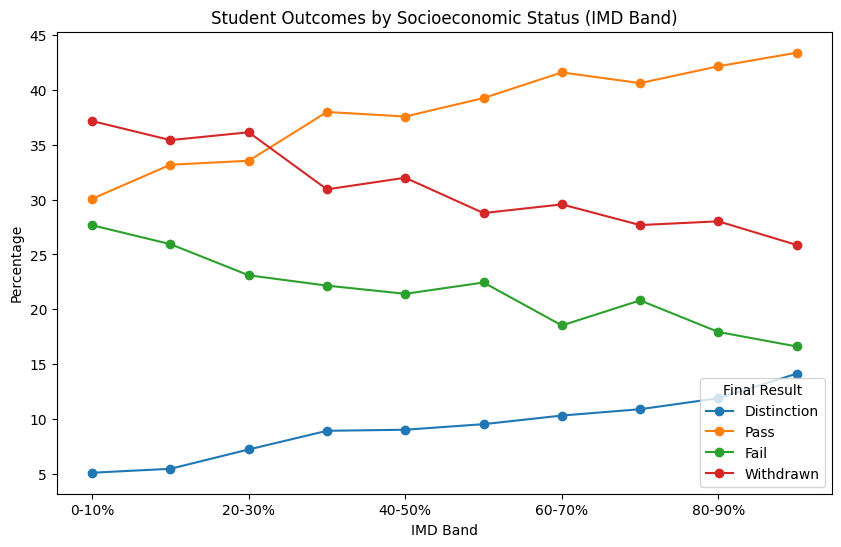

In [163]:
imd_results = (
    pd.crosstab(
        student_info["imd_band"],
        student_info["final_result"],
        normalize="index"
    ) * 100
)

imd_results[["Distinction", "Pass", "Fail", "Withdrawn"]].plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.title("Student Outcomes by Socioeconomic Status (IMD Band)")
plt.ylabel("Percentage")
plt.xlabel("IMD Band")
plt.legend(title="Final Result")
plt.show()

Three variables emerge as strong candidates for predictive modeling. Student engagement (total VLE clicks) shows a substantial relationship with academic outcomes, with distinction students generating nearly four times more clicks than students who failed or withdrew. Prior educational attainment demonstrates a strong gradient in student success, with postgraduate-qualified students earning distinctions at significantly higher rates than students with no formal qualifications. Socioeconomic status, measured through IMD band, also exhibits a consistent relationship with outcomes, as students from less deprived areas experience higher pass and distinction rates and lower withdrawal rates.

In [164]:
analysis_df.groupby("final_result")["studied_credits"].mean()

final_result
Distinction    71.759259
Fail           76.086926
Pass           74.220937
Withdrawn      91.430189
Name: studied_credits, dtype: float64

In [165]:
pd.crosstab(
    student_info["age_band"],
    student_info["final_result"],
    normalize="index"
) * 100

final_result,Distinction,Fail,Pass,Withdrawn
age_band,,,,
0-35,8.119770,22.798989,36.911611,32.169630
35-55,11.873211,18.997138,40.284109,28.845542
55<=,18.981481,13.425926,42.592593,25.000000


What's Emerging

At this point I've identified four variables that are almost certainly going to matter:

Variable	Signal Strength
sum_click	Very High
highest_education	High
imd_band	High
age_band	Moderate to High

In [166]:
import pandas as pd

student_info = pd.read_csv("../data/raw/studentInfo.csv")

student_info["age_band"].value_counts()

age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64

In [167]:
pd.crosstab(
    student_info["num_of_prev_attempts"],
    student_info["final_result"],
    normalize="index"
) * 100

final_result,Distinction,Fail,Pass,Withdrawn
num_of_prev_attempts,,,,
0,10.052426,20.164667,39.224517,30.558390
1,4.334647,30.585026,30.221279,34.859048
2,3.259259,34.962963,25.185185,36.592593
3,0.704225,40.140845,21.830986,37.323944
4,0.000000,30.769231,33.333333,35.897436
5,0.000000,46.153846,15.384615,38.461538
6,25.000000,25.000000,0.000000,50.000000


In [168]:
import pandas as pd

student_info = pd.read_csv("../data/raw/studentInfo.csv")
student_vle = pd.read_csv("../data/raw/studentVle.csv")

In [169]:
engagement = (
    student_vle
    .groupby("id_student")["sum_click"]
    .sum()
    .reset_index()
)

In [170]:
analysis_df = student_info.merge(
    engagement,
    on="id_student",
    how="left"
)

In [171]:
analysis_df.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,sum_click
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,934.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,1435.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,281.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,2158.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,1034.0


In [172]:
analysis_df.groupby("final_result")["studied_credits"].mean()

final_result
Distinction    71.759259
Fail           76.086926
Pass           74.220937
Withdrawn      91.430189
Name: studied_credits, dtype: float64

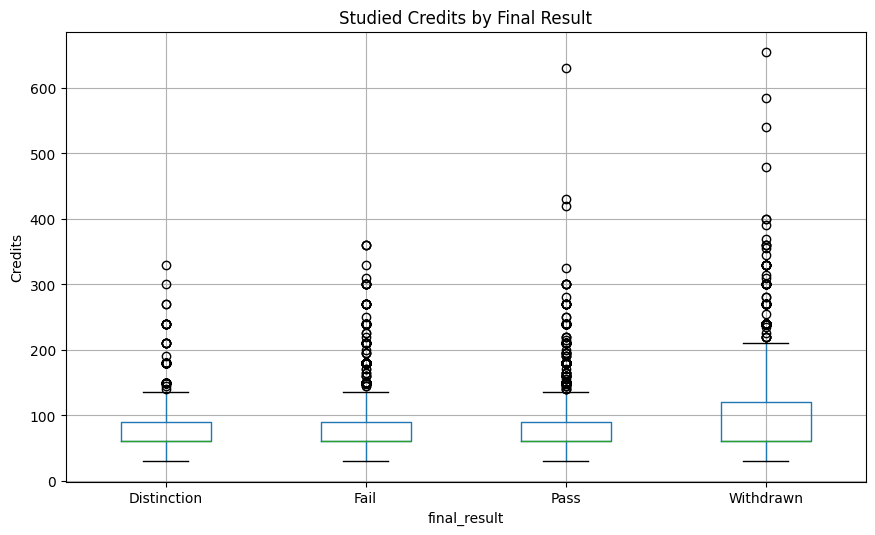

In [173]:
analysis_df.boxplot(
    column="studied_credits",
    by="final_result",
    figsize=(10,6)
)

plt.title("Studied Credits by Final Result")
plt.suptitle("")
plt.ylabel("Credits")
plt.show()

In [174]:
analysis_df.groupby("final_result")["studied_credits"].describe()

,count,mean,std,min,25%,50%,75%,max
final_result,,,,,,,,
Distinction,3024.0,71.759259,34.690593,30.0,60.0,60.0,90.0,330.0
Fail,7052.0,76.086926,38.846551,30.0,60.0,60.0,90.0,360.0
Pass,12361.0,74.220937,36.071382,30.0,60.0,60.0,90.0,630.0
Withdrawn,10156.0,91.430189,47.141690,30.0,60.0,60.0,120.0,655.0


Most students, regardless of outcome, studied approximately the same number of credits. However, students who withdrew were more likely to be enrolled in higher-credit loads, resulting in a substantially higher mean and upper-quartile value. This may indicate that heavier course loads are associated with increased withdrawal risk.

STEM STUDENT PERSISTENCE


In [185]:
courses["code_module"].value_counts()

code_module
BBB    4
DDD    4
FFF    4
EEE    3
GGG    3
AAA    2
CCC    2
Name: count, dtype: int64

In [186]:
stem_modules = [
    # fill in after we verify
]

stem_df = analysis_df[
    analysis_df["code_module"].isin(stem_modules)
].copy()

In [177]:
student_info["code_module"].value_counts()

code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64

In [187]:
courses

,code_module,code_presentation,module_presentation_length
0,AAA,2013J,268
1,AAA,2014J,269
2,BBB,2013J,268
3,BBB,2014J,262
4,BBB,2013B,240
5,BBB,2014B,234
6,CCC,2014J,269
7,CCC,2014B,241
8,DDD,2013J,261
9,DDD,2014J,262


In [188]:
stem_modules = ["CCC", "DDD", "EEE", "FFF", "GGG"]

In [189]:
student_info[
    student_info["code_module"].isin(
        ["CCC", "DDD", "EEE", "FFF", "GGG"]
    )
]["code_module"].value_counts()

code_module
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
Name: count, dtype: int64

In [190]:
stem_modules = ["CCC", "DDD", "EEE", "FFF", "GGG"]

stem_student_info = student_info[
    student_info["code_module"].isin(stem_modules)
].copy()

stem_student_info.shape

(23936, 12)

In [191]:
stem_student_info["final_result"].value_counts()

final_result
Pass           8797
Withdrawn      7642
Fail           5194
Distinction    2303
Name: count, dtype: int64

In [192]:
stem_student_info["final_result"].value_counts(normalize=True) * 100

final_result
Pass           36.752172
Withdrawn      31.926805
Fail           21.699532
Distinction     9.621491
Name: proportion, dtype: float64

In [193]:
student_info["final_result"].value_counts(normalize=True) * 100

final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64